In [33]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

In [34]:
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [35]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    
    history = model.fit(
        x_tr, to_categorical(y_tr, 10),
        validation_data=(x_v, to_categorical(y_v, 10)),
        epochs=epochs, 
        batch_size=batch_size,
        callbacks=cb, 
        verbose=0
    )
    
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    
    return history, test_acc, test_loss, elapsed



In [36]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [37]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


--- Running Task 1A: None (0-255) ---
Test Acc: 0.5506 | Test Loss: 2.6984 | Time: 43.0s

--- Running Task 1A: Min-Max [0,1] ---
Test Acc: 0.6647 | Test Loss: 1.4423 | Time: 43.0s

--- Running Task 1A: Standardized ---
Test Acc: 0.6544 | Test Loss: 2.2544 | Time: 43.5s


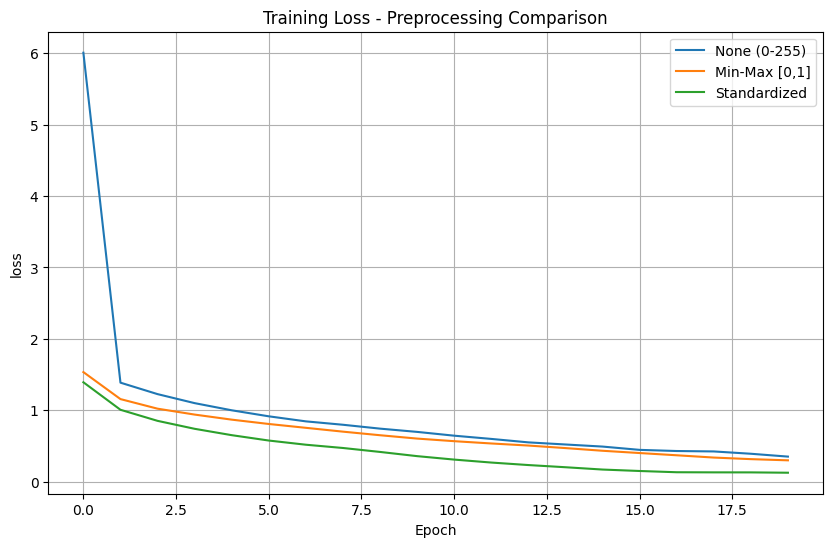

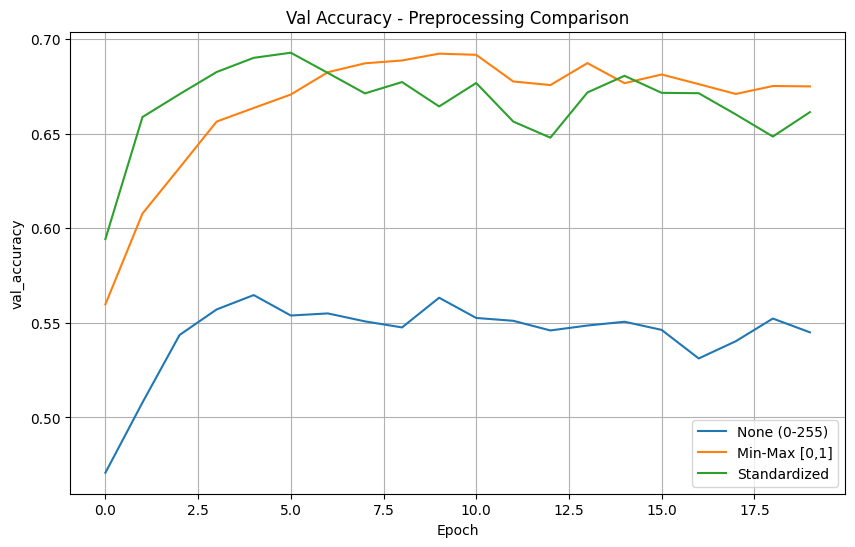

In [38]:

x_train_A, x_val_A, x_test_A = x_train, x_val, x_test

x_train_B, x_val_B, x_test_B = x_train / 255.0, x_val / 255.0, x_test / 255.0


mean = np.mean(x_train, axis=(0, 1, 2, 3))
std = np.std(x_train, axis=(0, 1, 2, 3))
x_train_C = (x_train - mean) / (std + 1e-7)
x_val_C = (x_val - mean) / (std + 1e-7)
x_test_C = (x_test - mean) / (std + 1e-7)

experiments_1a = {
    'None (0-255)': (x_train_A, x_val_A, x_test_A),
    'Min-Max [0,1]': (x_train_B, x_val_B, x_test_B),
    'Standardized': (x_train_C, x_val_C, x_test_C)
}


histories_1a = []
labels_1a = []

for name, (x_tr, x_v, x_te) in experiments_1a.items():
    print(f"\n--- Running Task 1A: {name} ---")
    model = build_baseline_cnn()
    hist, test_acc, test_loss, elapsed = train_and_evaluate(model, x_tr, y_train, x_v, y_val, x_te, y_test)
    histories_1a.append(hist)
    labels_1a.append(name)


plot_curves(histories_1a, labels_1a, metric='loss', title='Training Loss - Preprocessing Comparison')
plot_curves(histories_1a, labels_1a, metric='val_accuracy', title='Val Accuracy - Preprocessing Comparison')

In [39]:
x_train_std, x_val_std, x_test_std = x_train_C, x_val_C, x_test_C


print("\n--- Running Task 1B: No Augmentation ---")
model_no_aug = build_baseline_cnn()
hist_no_aug, _, _, _ = train_and_evaluate(
    model_no_aug, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test, epochs=40
)


print("\n--- Running Task 1B: With Augmentation ---")
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

model_with_aug = build_baseline_cnn()
start_aug = time.time()

hist_with_aug = model_with_aug.fit(
    datagen.flow(x_train_std, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_std, to_categorical(y_val, 10)),
    epochs=40,
    verbose=0
)
elapsed_aug = time.time() - start_aug
test_loss_aug, test_acc_aug = model_with_aug.evaluate(x_test_std, to_categorical(y_test, 10), verbose=0)
print(f"Test Acc (Aug): {test_acc_aug:.4f} | Time: {elapsed_aug:.1f}s")


--- Running Task 1B: No Augmentation ---
Test Acc: 0.6835 | Test Loss: 3.0632 | Time: 80.1s

--- Running Task 1B: With Augmentation ---
Test Acc (Aug): 0.7669 | Time: 780.3s


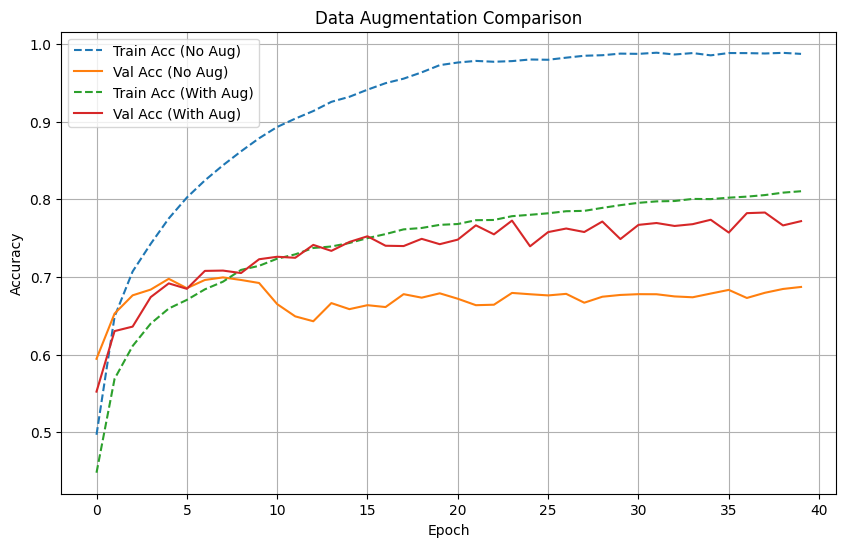

Overfit Gap (No Aug): 0.3004
Overfit Gap (With Aug): 0.0386


In [40]:
plt.figure(figsize=(10, 6))
plt.plot(hist_no_aug.history['accuracy'], label='Train Acc (No Aug)', linestyle='--')
plt.plot(hist_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(hist_with_aug.history['accuracy'], label='Train Acc (With Aug)', linestyle='--')
plt.plot(hist_with_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.title('Data Augmentation Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


gap_no_aug = hist_no_aug.history['accuracy'][-1] - hist_no_aug.history['val_accuracy'][-1]
gap_with_aug = hist_with_aug.history['accuracy'][-1] - hist_with_aug.history['val_accuracy'][-1]
print(f"Overfit Gap (No Aug): {gap_no_aug:.4f}")
print(f"Overfit Gap (With Aug): {gap_with_aug:.4f}")